In [1]:
# импортируем необходимые библиотеки, функции и классы
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

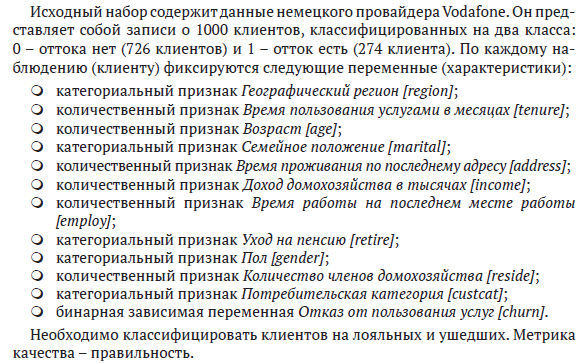

In [45]:
import urllib.request
urllib.request.urlretrieve(
    'https://github.com/MinyaevAndrey/Data_Preprocessing_in_Python/blob/main/code/Data/Vodafone_missing.csv?raw=true',
    'Vodafone_missing.csv'
)
# записываем CSV-файл в объект DataFrame
data = pd.read_csv('Vodafone_missing.csv', sep=';')
data.head(5)


,region,tenure,age,marital,address,income,employ,retire,gender,reside,custcat,churn
0,Region 2,13.0,44.0,mar,9.0,64.0,5.0,no,f,2.0,cat 1,1
1,Region 3,11.0,33.0,mar,7.0,136.0,5.0,no,f,6.0,cat 4,1
2,Region 3,68.0,52.0,mar,24.0,116.0,29.0,no,NaN,NaN,NaN,0
3,Region 2,NaN,33.0,NaN,12.0,NaN,NaN,no,NaN,1.0,cat 1,1
4,Region 2,23.0,30.0,mar,9.0,30.0,2.0,no,f,4.0,cat 3,0


In [46]:
# разбиваем данные на обучающие и тестовые: получаем обучающий
# массив признаков, тестовый массив признаков, обучающий массив
# меток, тестовый массив меток
X_train, X_test, y_train, y_test = train_test_split(data.drop('churn', axis=1),
                                                    data['churn'],
                                                    test_size=0.3,
                                                    stratify=data['churn'],
                                                    random_state=42)

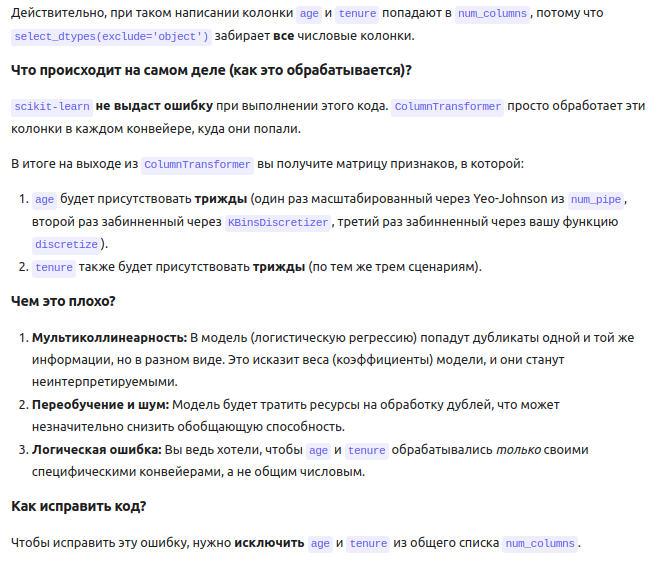

In [47]:
# создаем список:
# - категориальных признаков
# - количественных признаков, не предназначенных для биннинга
# - количественных признаков, предназначенных для биннинга
cat_columns = X_train.select_dtypes(include='object').columns.tolist()
num_columns = X_train.select_dtypes(exclude='object').columns.tolist()

# переменные tenure и age будут использованы как в виде количественных
# переменных, так и в виде дамми-переменных по итогам биннинга
age_col = ['age']
tenure_col = ['tenure']

# ИСКЛЮЧАЯ из них age и tenure!
# all_num_columns = X_train.select_dtypes(exclude='object').columns.tolist()
# num_columns = [col for col in all_num_columns if col not in age_col + tenure_col]

In [33]:
num_columns

['tenure', 'age', 'address', 'income', 'employ', 'reside']

In [48]:
# пишем функцию биннинга
def discretize(x, bins):
    # bins = [-np.inf, 20, 40, np.inf]
    return np.digitize(x, bins)

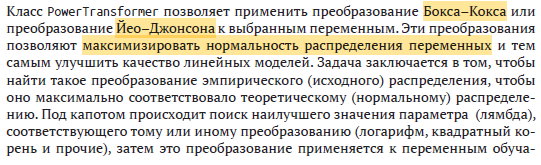

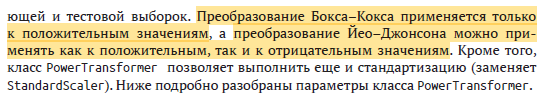

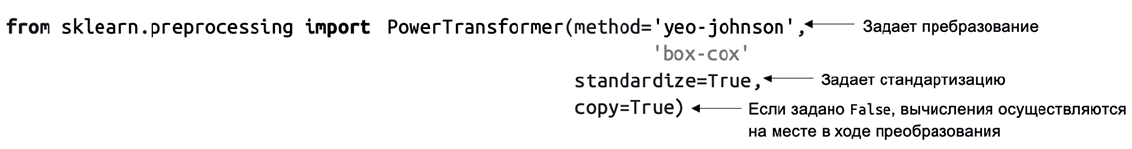

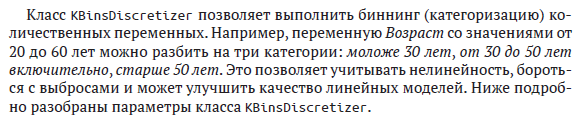

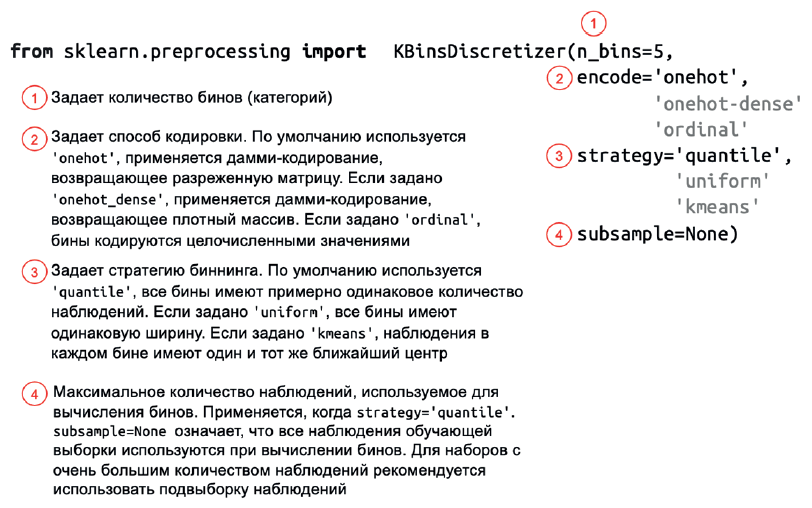

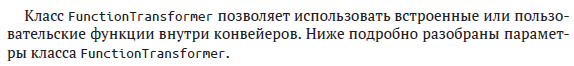

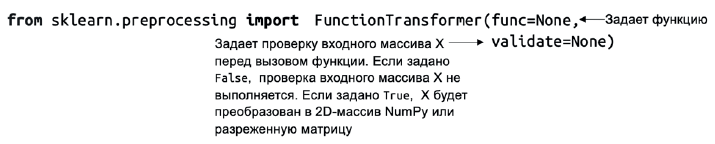

In [49]:
# создаем конвейер для количественных переменных,
# которые не будут подвергнуты биннингу
num_pipe = Pipeline(
    [
      ('imp', SimpleImputer()),
      ('yeo_john', PowerTransformer(method='yeo-johnson', standardize=True))
    ]
)

# создаем конвейер для age, которая будет
# подвергнута биннингу
age_bin_pipe = Pipeline(
    [
      ('imp', SimpleImputer()),
      ('disc', KBinsDiscretizer(encode='onehot-dense'))
    ]
)

# создаем конвейер для tenure, которая будет
# подвергнута биннингу
tenure_bin_pipe = Pipeline(
    [
      ('imp', SimpleImputer()),
      ('cust_disc', FunctionTransformer(discretize, validate=False)),
      ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ]
)

# создаем конвейер для категориальных переменных
cat_pipe = Pipeline(
    [
      ('imp', SimpleImputer()),
      ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ]
)

In [50]:
# создаем список трехэлементных кортежей, в котором
# первый элемент кортежа - название конвейера с
# преобразованиями для определенного типа признаков
transformers = [('num', num_pipe, num_columns),
                ('age_bin', age_bin_pipe, age_col),
                ('tenure_bin', tenure_bin_pipe, tenure_col),
                ('cat', cat_pipe, cat_columns)]

In [51]:
# передаем список трансформеров в ColumnTransformer
transformer = ColumnTransformer(transformers=transformers)
transformer

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imp', SimpleImputer()),
                                                 ('yeo_john',
                                                  PowerTransformer())]),
                                 ['tenure', 'age', 'address', 'income',
                                  'employ', 'reside']),
                                ('age_bin',
                                 Pipeline(steps=[('imp', SimpleImputer()),
                                                 ('disc',
                                                  KBinsDiscretizer(encode='onehot-dense'))]),
                                 ['age']),
                                ('tenure_bin',
                                 Pipeline(steps=[('imp', SimpleImputer()),
                                                 ('cust_disc',
                                                  FunctionTransformer(func=<function discretize at 0x78f2754bb420>)),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['tenure']),
                                ('cat',
                                 Pipeline(steps=[('imp', SimpleImputer()),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['region', 'marital', 'retire', 'gender',
                                  'custcat'])])

In [52]:
# задаем итоговый конвейер
ml_pipe = Pipeline(
    [
        ('tr', transformer),
        ('lr', LogisticRegression(C=0.1,
                                  solver='lbfgs',
                                  max_iter=200))
    ]
)

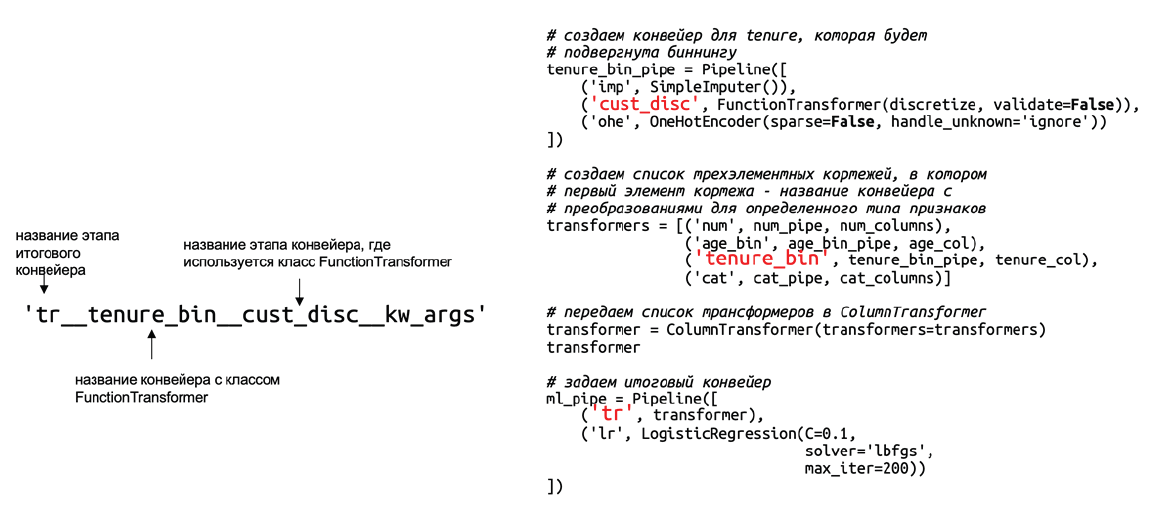

In [53]:
# задаем сетку гиперпараметров
param_grid = {
    'tr__tenure_bin__cust_disc__kw_args': [
        {'bins': [-np.inf, 25, 40, np.inf]},
        {'bins': [-np.inf, 30, 40, 50, np.inf]},
        {'bins': [-np.inf, 25, 45, 55, np.inf]}
    ],
    'tr__num__imp__strategy'   : ['mean', 'median', 'constant'],
    'tr__age_bin__disc__n_bins': [2, 3],
    'tr__cat__imp__strategy'   : ['most_frequent', 'constant']
}

In [54]:
# создаем экземпляр класса GridSearchCV, передав конвейер,
# сетку гиперпараметров и указав количество
# блоков перекрестной проверки, отключив запись метрик
# для обучающих блоков перекрестной проверки в атрибут cv_results_
gs = GridSearchCV(ml_pipe, param_grid, cv=5, return_train_score=False)

# выполняем поиск по сетке
gs.fit(X_train, y_train)

# смотрим наилучшие значения гиперпараметров
print('Наилучшие значения гиперпараметров:\n{}'.format(gs.best_params_))

# смотрим наилучшее значение правильности
print('Наилучшее значение правильности: {:.3f}'.format(gs.best_score_))

# смотрим значение правильности на тестовой выборке
print('Значение правильности на тестовой выборке: {:.3f}'.format(gs.score(X_test, y_test)))

Наилучшие значения гиперпараметров:
{'tr__age_bin__disc__n_bins': 3, 'tr__cat__imp__strategy': 'most_frequent', 'tr__num__imp__strategy': 'constant', 'tr__tenure_bin__cust_disc__kw_args': {'bins': [-inf, 30, 40, 50, inf]}}
Наилучшее значение правильности: 0.761
Значение правильности на тестовой выборке: 0.760


In [57]:
# запишем результаты перекрестной
# проверки в DataFrame
results = pd.DataFrame(gs.cv_results_)

# создаем копию для работы
table_df = results.copy()

# преобразуем словари в строки
table_df['param_tr__tenure_bin__cust_disc__kw_args'] = table_df['param_tr__tenure_bin__cust_disc__kw_args'].astype(str)

# превращаем в сводную таблицу
table = table_df.pivot_table(values=['mean_test_score'],
                            index=['param_tr__cat__imp__strategy',
                                   'param_tr__num__imp__strategy',
                                   'param_tr__age_bin__disc__n_bins',
                                   'param_tr__tenure_bin__cust_disc__kw_args'])

# сортируем по убыванию правильности
table = table.sort_values(by='mean_test_score', ascending=False)
print(table)

                                                                                                                                    mean_test_score
param_tr__cat__imp__strategy param_tr__num__imp__strategy param_tr__age_bin__disc__n_bins param_tr__tenure_bin__cust_disc__kw_args                 
most_frequent                constant                     3                               {'bins': [-inf, 30, 40, 50, inf]}                0.761429
constant                     constant                     3                               {'bins': [-inf, 30, 40, 50, inf]}                0.757143
most_frequent                constant                     2                               {'bins': [-inf, 25, 45, 55, inf]}                0.755714
                                                          3                               {'bins': [-inf, 25, 40, inf]}                    0.755714
                             mean                         3                               {'bins': [-inf, 30, 40

In [59]:
results = pd.DataFrame(gs.cv_results_)

# создаем копию для работы
results_copy = results.copy()

# преобразуем словари в строки
results_copy['param_tr__tenure_bin__cust_disc__kw_args'] = results_copy['param_tr__tenure_bin__cust_disc__kw_args'].astype(str)

# теперь группируем и сортируем
table = results_copy.groupby(['param_tr__cat__imp__strategy',
                              'param_tr__num__imp__strategy',
                              'param_tr__age_bin__disc__n_bins',
                              'param_tr__tenure_bin__cust_disc__kw_args'])['mean_test_score'].mean()

table = table.sort_values(ascending=False)
print(table)

param_tr__cat__imp__strategy  param_tr__num__imp__strategy  param_tr__age_bin__disc__n_bins  param_tr__tenure_bin__cust_disc__kw_args
most_frequent                 constant                      3                                {'bins': [-inf, 30, 40, 50, inf]}           0.761429
constant                      constant                      3                                {'bins': [-inf, 30, 40, 50, inf]}           0.757143
most_frequent                 constant                      2                                {'bins': [-inf, 25, 45, 55, inf]}           0.755714
                                                            3                                {'bins': [-inf, 25, 40, inf]}               0.755714
                              mean                          3                                {'bins': [-inf, 30, 40, 50, inf]}           0.755714
                              median                        3                                {'bins': [-inf, 30, 40, 50, inf]}          

In [16]:
# извлекаем дамми-переменные для списка с переменной age
age = gs.best_estimator_['tr'].named_transformers_['age_bin']
age_ohe_columns = list(age.named_steps['disc'].get_feature_names_out(
    input_features=age_col))
age_ohe_columns

['age_0.0', 'age_1.0']

In [17]:
# извлекаем дамми-переменные для списка с переменной tenure
tenure = gs.best_estimator_['tr'].named_transformers_['tenure_bin']
tenure_ohe_columns = list(tenure.named_steps['ohe'].get_feature_names_out(
    input_features=tenure_col))
tenure_ohe_columns

['tenure_1', 'tenure_2', 'tenure_3']

In [18]:
# извлекаем дамми-переменные для списка
# категориальных признаков
cat = gs.best_estimator_['tr'].named_transformers_['cat']
сat_ohe_columns = list(cat.named_steps['ohe'].get_feature_names_out(
    input_features=cat_columns))
сat_ohe_columns

['region_Region 1',
 'region_Region 2',
 'region_Region 3',
 'marital_mar',
 'marital_unmar',
 'retire_no',
 'retire_yes',
 'gender_f',
 'gender_m',
 'custcat_cat 1',
 'custcat_cat 2',
 'custcat_cat 3',
 'custcat_cat 4']

In [19]:
# добавляем к списку количественных переменных
# остальные списки
all_cols = (num_columns + age_ohe_columns +
            tenure_ohe_columns + сat_ohe_columns)

In [20]:
# извлекаем константу
intercept = np.round(gs.best_estimator_['lr'].intercept_[0], 3)
# извлекаем коэффициенты
coef = np.round(gs.best_estimator_['lr'].coef_, 3)

# печатаем название "Константа"
print("Константа:", intercept)
# печатаем название "Регрессионные коэффициенты"
print("Регрессионные коэффициенты:")
# для удобства сопоставим каждому названию
# предиктора соответствующий коэффициент
for c, feature in zip(coef[0], all_cols):
    print(feature, c)

Константа: -1.162
Регрессионные коэффициенты:
tenure -0.757
age -0.168
address -0.015
income 0.175
employ -0.253
reside -0.105
age_0.0 -0.031
age_1.0 0.032
tenure_1 0.142
tenure_2 -0.121
tenure_3 -0.021
region_Region 1 -0.036
region_Region 2 0.061
region_Region 3 -0.025
marital_mar 0.048
marital_unmar -0.048
retire_no 0.009
retire_yes -0.009
gender_f -0.026
gender_m 0.026
custcat_cat 1 -0.257
custcat_cat 2 0.35
custcat_cat 3 -0.436
custcat_cat 4 0.344
